# 04 · Forward-looking reserve — expected credit loss on the active book

This is where the models do the real work. Instead of an observed-rate cash-flow
buffer, we estimate the **expected credit loss (ECL) on the loans that are still
open today**, the way IFRS 9 / CECL provisioning works:

`ECL = P(defaults in remaining life | already survived to its current age) × LGD × outstanding balance`

- **Survival model** → remaining-life probability of default, conditioned on each loan's age today (left-truncation). Trained on the resolved history.
- **LGD model** → loss severity at the loan's *projected* default time. Modelled on the amortization drivers (months-on-book, term), since timing is the real driver of severity.
- **Exposure** → current outstanding principal (`out_prncp`), not the original amount.

Everything uses information observable *today*; nothing reaches into the future.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from lifelines import CoxPHFitter
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SNAP = pd.Timestamp("2019-01-01")   # data snapshot
df = pd.read_parquet("../data/processed/loans_clean.parquet")
df["grade_num"] = df["grade"].map({"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7})
print(f"Loaded {len(df):,} loans")

Loaded 2,258,957 loans


## The live book — resolved (training history) vs active (what we reserve against)

Resolved loans (Fully Paid / Charged Off / Default) have known outcomes and train
the models. Active loans (Current / In-grace / Late) are still open — the book the
reserve covers. Exposure is their outstanding principal.

In [2]:
active = df[~df["resolved"]]
exposure = active["out_prncp"].sum()
print(f"Resolved (training): {df['resolved'].sum():,}")
print(f"Active (live book):  {len(active):,}  |  exposure ${exposure/1e9:.2f}B")
print(active["loan_status"].value_counts().to_string())

Resolved (training): 1,347,725
Active (live book):  911,232  |  exposure $9.49B
loan_status
Current               877018
Late (31-120 days)     21443
In Grace Period         8427
Late (16-30 days)       4344


## Models, trained on the resolved history

`fit_survival` fits a Cox model of time-to-default (the same survival approach as
notebook 03). `fit_lgd` fits loss severity on charged-off loans using only the
amortization drivers — months-on-book and term — because that is what mechanically
determines how much principal is still outstanding when a loan fails (notebook 03
shows the other features carry no reliable signal). `predict_ecl` applies both to a
book of loans: it computes each loan's remaining-life PD conditioned on its current
age, its expected default month, the LGD at that month, and `PD × LGD × exposure`.

In [3]:
SF   = ["int_rate","dti","fico","annual_inc","grade_num","term"]          # survival features
LF   = ["months_obs","term"]                                              # LGD = f(timing, term)
PRED = ["int_rate","dti","fico","loan_amnt","annual_inc","revol_util","grade_num","term"]

def fit_survival(train, n=150_000):
    s = train[["months_obs","delq90"]+SF].dropna()
    if len(s) > n:
        s = s.sample(n, random_state=42)
    return CoxPHFitter().fit(s, "months_obs", "delq90")

def fit_lgd(train):
    t = train[train["delq90"] == 1].copy()
    t["lgd"] = ((t["loan_amnt"]-t["total_pymnt"]).clip(lower=0)/t["loan_amnt"]).clip(0,1)
    t = t[LF+["lgd"]].dropna()
    return sm.OLS(t["lgd"], sm.add_constant(t[LF])).fit()

def predict_ecl(book, cph, ols, ead_col="out_prncp", age_col="age", use_status=True):
    book = book.dropna(subset=SF+["loan_amnt","revol_util",ead_col,age_col,"term","delq90"]).copy()
    bs = cph.baseline_survival_["baseline survival"]
    bidx, bval = bs.index.values, np.clip(bs.values, 1e-9, 1.0)
    S0 = lambda t: np.clip(np.interp(t, bidx, bval), 1e-9, 1.0)
    hr = cph.predict_partial_hazard(book[SF]).values
    a  = book[age_col].clip(0, 72).values
    T  = np.minimum(book["term"].values, 72)
    S_a, S_T = S0(a)**hr, S0(T)**hr
    rem_pd = np.clip(1 - S_T/np.clip(S_a, 1e-9, 1), 0, 1)
    # expected default month, conditional on defaulting in (age, term]
    num = np.zeros(len(book)); den = np.zeros(len(book)); s_prev = S0(np.zeros(len(book)))**hr
    for m in range(1, 73):
        s_m = S0(np.full(len(book), m))**hr
        dP  = np.clip(s_prev - s_m, 0, None)
        mask = (m > a) & (m <= T)
        num += np.where(mask, m*dP, 0.0); den += np.where(mask, dP, 0.0); s_prev = s_m
    exp_month = np.where(den > 1e-9, num/np.where(den > 1e-9, den, 1.0), (a+T)/2)
    if use_status:                       # already-delinquent loans are defaulting now
        bad = book["delq90"].values == 1
        rem_pd = np.where(bad, 1.0, rem_pd); exp_month = np.where(bad, a, exp_month)
    Xl = book[PRED].copy(); Xl["months_obs"] = exp_month
    lgd = np.clip(ols.predict(sm.add_constant(Xl[LF], has_constant="add")).values, 0, 1)
    ead = book[ead_col].values
    return book.assign(rem_pd=rem_pd, exp_month=exp_month, lgd=lgd, ead=ead, ecl=rem_pd*lgd*ead)

cph = fit_survival(df)   # survival trained on the full history (resolved + censored active)
ols = fit_lgd(df)        # LGD trained on charged-off loans
print("models fitted")

models fitted


## Expected credit loss on the active book

Active exposure: $9.48B
Expected credit loss: $582M  (6.14% of exposure)
Avg remaining-life PD 19.1% | avg projected LGD 20.8% | avg projected default month 29

ECL by grade:
       ead_B  pd_pct   ecl_M  loss_pct
grade                                 
A       2.00    8.45   57.91      2.90
B       2.67   13.48  116.79      4.38
C       2.84   20.86  176.44      6.22
D       1.36   32.28  140.47     10.31
E       0.45   43.64   62.68     13.82
F       0.12   55.32   20.13     16.83
G       0.04   66.88    7.83     19.60


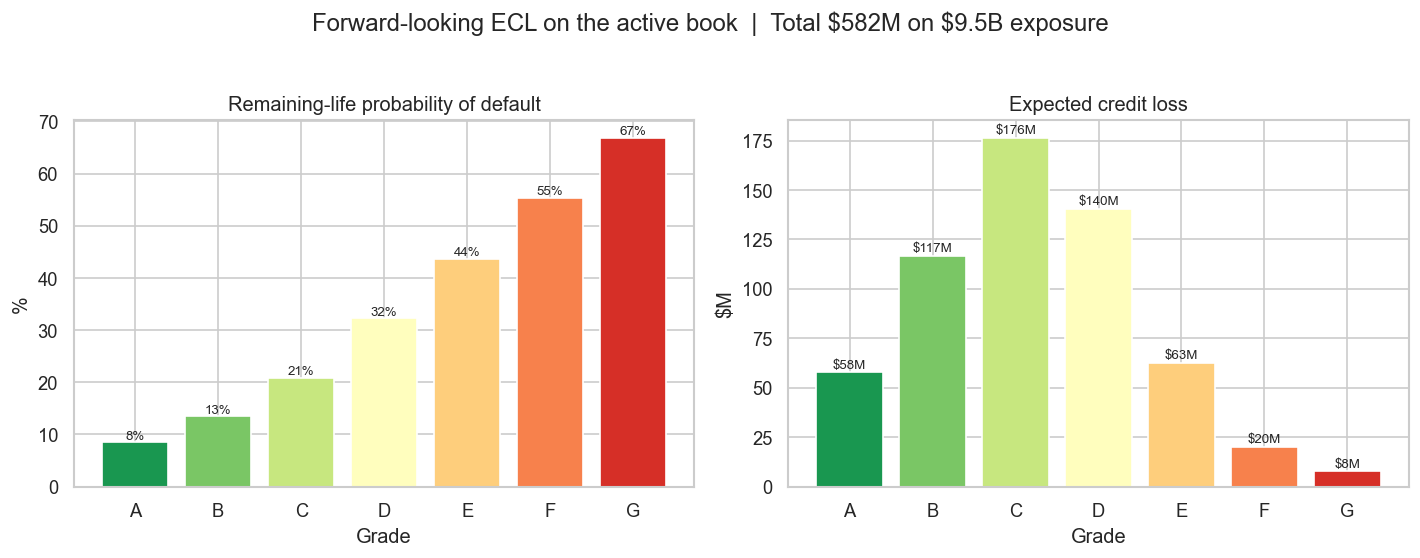

In [4]:
sc  = predict_ecl(active, cph, ols)
ecl = sc["ecl"].sum(); exposure = sc["ead"].sum()
print(f"Active exposure: ${exposure/1e9:.2f}B")
print(f"Expected credit loss: ${ecl/1e6:,.0f}M  ({ecl/exposure:.2%} of exposure)")
print(f"Avg remaining-life PD {sc['rem_pd'].mean():.1%} | avg projected LGD {sc['lgd'].mean():.1%} "
      f"| avg projected default month {sc['exp_month'].mean():.0f}")

g = sc.groupby("grade").agg(ead=("ead","sum"), ecl=("ecl","sum"), pd=("rem_pd","mean"))
g["pct"] = g["ecl"]/g["ead"]
print("\nECL by grade:")
print((g.assign(ead_B=g["ead"]/1e9, ecl_M=g["ecl"]/1e6, pd_pct=g["pd"]*100, loss_pct=g["pct"]*100)
        [["ead_B","pd_pct","ecl_M","loss_pct"]]).round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
cols = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(g)))
ax[0].bar(g.index, g["pd"]*100, color=cols)
ax[0].set_title("Remaining-life probability of default"); ax[0].set_ylabel("%"); ax[0].set_xlabel("Grade")
for i,v in enumerate(g["pd"]*100): ax[0].text(i, v+0.6, f"{v:.0f}%", ha="center", fontsize=8)
ax[1].bar(g.index, g["ecl"]/1e6, color=cols)
ax[1].set_title("Expected credit loss"); ax[1].set_ylabel("$M"); ax[1].set_xlabel("Grade")
for i,v in enumerate(g["ecl"]/1e6): ax[1].text(i, v+2, f"${v:.0f}M", ha="center", fontsize=8)
plt.suptitle(f"Forward-looking ECL on the active book  |  Total \${ecl/1e6:,.0f}M on \${exposure/1e9:.1f}B exposure", y=1.03)
plt.tight_layout()
plt.savefig("../output/figures/ecl_by_grade.png", dpi=150, bbox_inches="tight")
plt.show()

## A bad year is *systemic*, not random

With ~900k loans, individual-loan default randomness diversifies almost completely:
a Monte-Carlo over independent defaults gives a 95th percentile essentially equal to
the mean (loss std dev is a rounding error at this scale). The reserve's real
uncertainty is **systemic** — a downturn lifting everyone's default rate at once — so
we stress the portfolio by scaling PD rather than resampling coin-flips.

Idiosyncratic loss std dev: $1.3M  ->  95th pct (mean+1.645sd) $584M  (diversified away)
  Base           $582M (6.14% of exposure)
  Mild +25%      $696M (7.35% of exposure)
  Moderate +50%  $805M (8.49% of exposure)
  Severe x2      $1,007M (10.62% of exposure)


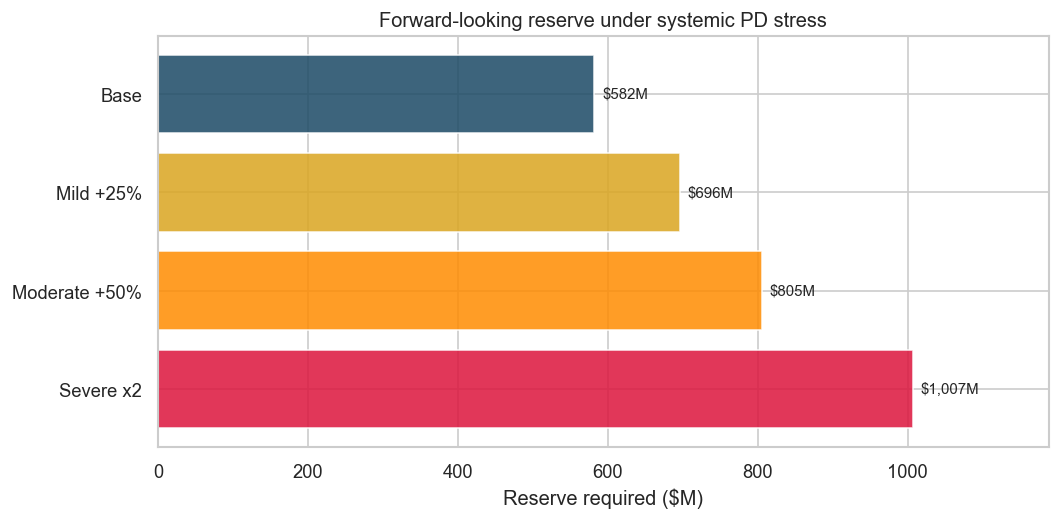

In [5]:
var = (sc["rem_pd"]*(1-sc["rem_pd"])*(sc["lgd"]*sc["ead"])**2).sum(); sd = var**0.5
print(f"Idiosyncratic loss std dev: ${sd/1e6:.1f}M  ->  95th pct (mean+1.645sd) ${(ecl+1.645*sd)/1e6:,.0f}M  (diversified away)")

scen = [("Base", 1.0), ("Mild +25%", 1.25), ("Moderate +50%", 1.5), ("Severe x2", 2.0)]
vals = [float((np.minimum(sc["rem_pd"]*k, 1.0)*sc["lgd"]*sc["ead"]).sum()) for _,k in scen]
for (lab,_), v in zip(scen, vals):
    print(f"  {lab:14s} ${v/1e6:,.0f}M ({v/exposure:.2%} of exposure)")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#1b4965","goldenrod","darkorange","crimson"]
labels = [s for s,_ in scen]
bars = ax.barh(labels[::-1], [v/1e6 for v in vals][::-1], color=colors[::-1], alpha=0.85)
for b,v in zip(bars, vals[::-1]):
    ax.text(b.get_width()+10, b.get_y()+b.get_height()/2, f"${v/1e6:,.0f}M", va="center", fontsize=9)
ax.set_xlabel("Reserve required ($M)"); ax.set_xlim(0, max(vals)/1e6*1.18)
ax.set_title("Forward-looking reserve under systemic PD stress")
plt.tight_layout()
plt.savefig("../output/figures/ecl_stress.png", dpi=150)
plt.show()

## Backtest — does it match what actually happened?

The honest test: train the models on a **past slice** (loans issued ≤ 2014), then
predict each vintage's lifetime loss rate and compare to what was *realized*. On
matured, normal-condition vintages predicted tracks realized closely. Two gaps are
expected and informative: the 2007–08 **crisis** vintages are under-predicted (the
model has no macro variable), and the most **recent** vintages show predicted above
realized because those loans simply haven't had time to default yet (maturation).

            predicted  realized
issue_year                     
2007.0            6.2      15.8
2008.0            5.9      12.4
2009.0            5.4       7.1
2010.0            5.9       6.3
2011.0            6.7       7.2
2012.0            7.5       6.8
2013.0            7.8       5.8
2014.0            7.5       6.7
2015.0            7.0       7.9
2016.0            7.2       8.2
2017.0            7.3       6.1
2018.0            6.7       1.6


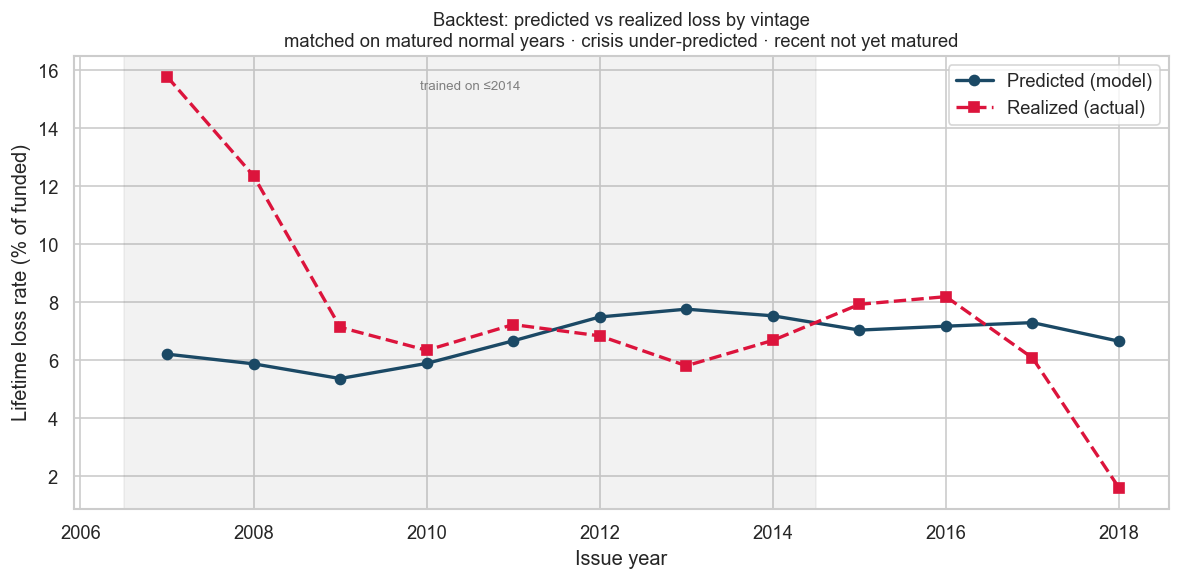

In [6]:
bt = df[df["issue_year"] <= 2014]
cph_bt, ols_bt = fit_survival(bt), fit_lgd(bt)

life = df.copy(); life["age0"] = 0.0
life = predict_ecl(life, cph_bt, ols_bt, ead_col="loan_amnt", age_col="age0", use_status=False)
CHARGED = {"Charged Off","Default","Does not meet the credit policy. Status:Charged Off"}
life["_loss"] = np.where(life["loan_status"].isin(CHARGED),
                         (life["loan_amnt"]-life["total_pymnt"]).clip(lower=0), 0.0)
by = life.groupby("issue_year").apply(lambda d: pd.Series({
        "predicted": d["ecl"].sum()/d["loan_amnt"].sum()*100,
        "realized":  d["_loss"].sum()/d["loan_amnt"].sum()*100}), include_groups=False)
print(by.round(1).to_string())

yrs = by.index.values
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yrs, by["predicted"], "o-", color="#1b4965", lw=2, label="Predicted (model)")
ax.plot(yrs, by["realized"], "s--", color="crimson", lw=2, label="Realized (actual)")
ax.axvspan(yrs.min()-0.5, 2014.5, color="gray", alpha=0.10)
ax.text(2010.5, ax.get_ylim()[1]*0.93, "trained on ≤2014", fontsize=8, color="gray", ha="center")
ax.set_xlabel("Issue year"); ax.set_ylabel("Lifetime loss rate (% of funded)")
ax.set_title("Backtest: predicted vs realized loss by vintage\n"
             "matched on matured normal years · crisis under-predicted · recent not yet matured", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig("../output/figures/ecl_backtest.png", dpi=150, bbox_inches="tight")
plt.show()